<span style="font-size: 25px;">Case Study 2: Analysis of US Births Dataset (2000–2014)</span>

<span style="font-size: 15px;">The objective of this case study is to analyze the US Births dataset from 2000 to 2014 obtained from the Social Security Administration (SSA). The analysis focuses on identifying patterns in daily birth counts across different days of the week and throughout the year. Statistical techniques and visualization methods are used to understand the distribution, variability, and trends in the birth data.</span>

<span style="font-size: 20px;">Importing the necessary libraries</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<span style="font-size: 20px;">Loading the Dataset.</span>

In [2]:
df=pd.read_csv("US_births_2000-2014_SSA.csv")

In [3]:
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.0,6,9083.0,01-01-2000
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
...,...,...,...,...,...,...
5474,2014,12,27.0,6,8656.0,12/27/2014
5475,2014,12,28.0,7,7724.0,12/28/2014
5476,2014,12,29.0,1,12811.0,12/29/2014
5477,2014,12,30.0,2,13634.0,12/30/2014


<span style="font-size: 15px;">The dataset is loaded using the pandas library. It contains daily birth records in the United States between 2000 and 2014.</span>

<span style="font-size: 20px;">Dataset Overview</span>

In [4]:
df.shape

(5479, 6)

In [5]:
df.describe()

,year,month,date_of_month,day_of_week,births
count,5479.000000,5479.000000,5478.000000,5479.000000,5465.000000
mean,2006.999270,6.522723,15.727455,3.999817,11348.814456
std,4.321085,3.449075,8.799535,2.000502,2327.445105
min,2000.000000,1.000000,1.000000,1.000000,5728.000000
25%,2003.000000,4.000000,8.000000,2.000000,8739.000000
50%,2007.000000,7.000000,16.000000,4.000000,12343.000000
75%,2011.000000,10.000000,23.000000,6.000000,13083.000000
max,2014.000000,12.000000,31.000000,7.000000,16081.000000


In [6]:
df.columns

Index(['year', 'month', 'date_of_month', 'day_of_week', 'births', 'date'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5479 non-null   int64  
 1   month          5479 non-null   int64  
 2   date_of_month  5478 non-null   float64
 3   day_of_week    5479 non-null   int64  
 4   births         5465 non-null   float64
 5   date           5479 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 257.0+ KB


In [8]:
df.isnull().sum()

year              0
month             0
date_of_month     1
day_of_week       0
births           14
date              0
dtype: int64

In [9]:
df.duplicated().sum()

0

<span style="font-size: 15px;">To understand the structure of the dataset, we inspect the data shape, data types, summary statistics, check for missing values and duplicate values</span>

<span style="font-size:20px">Data Preprocessing</span>

<span style="font-size: 15px;">Dropping the null values in the data</span>

In [10]:
nan_index = df[df["date_of_month"].isnull()|df["births"].isnull()].index

In [11]:
nan_index

Index([5, 10, 12, 49, 95, 150, 151, 152, 292, 293, 351, 443, 528, 5452, 5478], dtype='int64')

In [12]:
df.drop(nan_index,inplace=True)

In [13]:
df.isnull().sum()

year             0
month            0
date_of_month    0
day_of_week      0
births           0
date             0
dtype: int64

<span style="font-size: 15px;">In this step,we prepare the dataset for analysis. The column which as missing values are been droped using nan_index</span>

<span style="font-size: 20px;">Remove all the rows on weekdays that are less than 10,000</span>

In [14]:
df = df[~((df['day_of_week'] <= 5) & (df['births'] < 10000))]

In [15]:
df = df.reset_index(drop=True)

In [16]:
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.0,6,9083.0,01-01-2000
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
...,...,...,...,...,...,...
5347,2014,12,26.0,5,10386.0,12/26/2014
5348,2014,12,27.0,6,8656.0,12/27/2014
5349,2014,12,28.0,7,7724.0,12/28/2014
5350,2014,12,29.0,1,12811.0,12/29/2014


<span style="font-size: 15px;">We Created a column for births which is less than 10,000 , then we dropped the row by applying the given condition and dropped the created column.</span>

<span style="font-size: 20px;">What is the average number of births per day for each day of the week?</span>

In [17]:
births_per_day = df.groupby('day_of_week')['births'].mean().round(2)
print("Average births per day of the week:")
print(births_per_day)

Average births per day of the week:
day_of_week
1    12145.92
2    13191.04
3    12969.10
4    13009.24
5    12708.01
6     8562.19
7     7517.73
Name: births, dtype: float64


<span style="font-size: 15px;">The average number of births for each day of the week is calculated to observe which days have higher birth rates.</span>

<span style="font-size: 20px;">What is the median number of births per day for each day of the week?</span>

In [18]:
births_per_day = df.groupby('day_of_week')['births'].median()
print("Median number of births per day of the week:")
print(births_per_day)

Median number of births per day of the week:
day_of_week
1    12141.5
2    13206.0
3    12949.5
4    12985.0
5    12667.0
6     8573.5
7     7511.5
Name: births, dtype: float64


<span style="font-size: 15px;">The median birth count is calculated to understand the central tendency of the data.</span>

<span style="font-size: 20px;">How dispersed are the number of births per day for each day of the week?</span>

In [19]:
std_dev = df.groupby('day_of_week')['births'].std()
print("Standard Deviation of births per day:",std_dev.round(2))

Standard Deviation of births per day: day_of_week
1    628.93
2    685.68
3    735.73
4    723.97
5    750.82
6    499.05
7    399.79
Name: births, dtype: float64


In [20]:
variance = df.groupby('day_of_week')['births'].var()
print("Variance of births per day:",variance.round(2))

Variance of births per day: day_of_week
1    395552.07
2    470151.38
3    541305.72
4    524133.98
5    563736.66
6    249049.85
7    159831.92
Name: births, dtype: float64


<span style="font-size:15px;">Dispersion measures how spread out the birth counts are across different days of the week. To analyze this variability, both variance and standard deviation are calculated. These measures help understand the level of variability in birth counts across different days of the week.</span>

<span style="font-size: 20px;">What is the interquartile range (IQR) of the number of births per day for each day of the week?</span>

In [21]:
Q1 = df.groupby('day_of_week')['births'].quantile(0.25)
Q3 = df.groupby('day_of_week')['births'].quantile(0.75)
IQR = Q3 - Q1
print("The Interquartile Range(IQR) of the number of births per day for each day of the week is",IQR)

The Interquartile Range(IQR) of the number of births per day for each day of the week is day_of_week
1    863.50
2    883.25
3    934.75
4    947.00
5    947.00
6    606.75
7    516.00
Name: births, dtype: float64


<span style="font-size:15px;">The IQR helps measure the spread of the middle 50% of the data and is useful for identifying outliers. A larger IQR indicates greater variability in birth counts, while a smaller IQR suggests that the birth counts are more consistent.</span>

<span style="font-size: 20px;">Find the outliers for the number of births per day for each day of the week using the IQR method</span>

In [22]:
for day in df['day_of_week'].unique():
    data=df[df['day_of_week']==day]['births']
    Q1=data.quantile(0.25)
    Q3=data.quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    
    outliers=data[(data<lower)|(data>upper)]
    print(f"Day {day}: {len(outliers)} outliers")

Day 6: 14 outliers
Day 7: 6 outliers
Day 1: 8 outliers
Day 2: 12 outliers
Day 3: 13 outliers
Day 5: 14 outliers
Day 4: 14 outliers


<span style="font-size:15px;">
The IQR method identifies unusual birth counts that fall outside the expected range for each day of the week. These outliers may occur due to special events, holidays, reporting errors, or unusual birth patterns. Detecting outliers helps improve the reliability of statistical analysis and better understand variations in the dataset.</span>

<span style="font-size: 20px;">Produce box and whisker plots for the number of births per day for each day of the week</span>

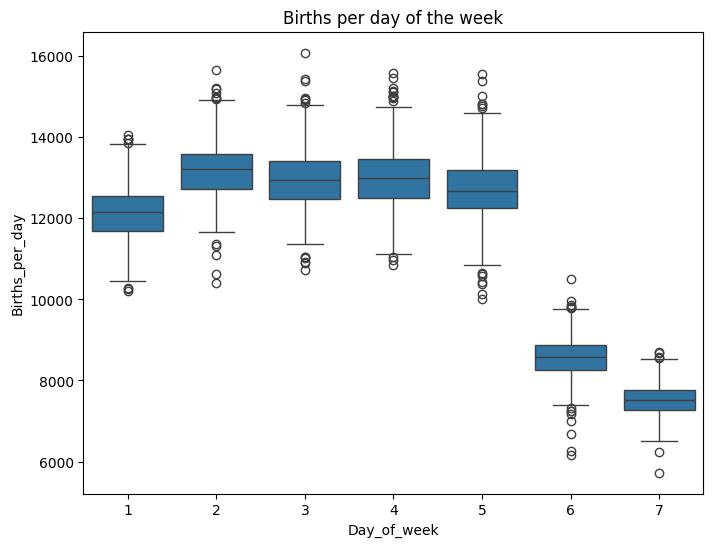

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x="day_of_week", y="births")
plt.title('Births per day of the week')
plt.xlabel('Day_of_week')
plt.ylabel('Births_per_day')
plt.show()

<span style="font-size:15px;">The box plot shows that births are higher during weekdays and lower during weekends, indicating that many are born during working days.The presence of dots outside the whiskers indicates outliers, which represent unusually high or low birth counts that may occur due to holidays or irregular events.</span>

<span style="font-size: 20px;">Produce histograms and KDE plots for the number of births per day for each day of the week</span>

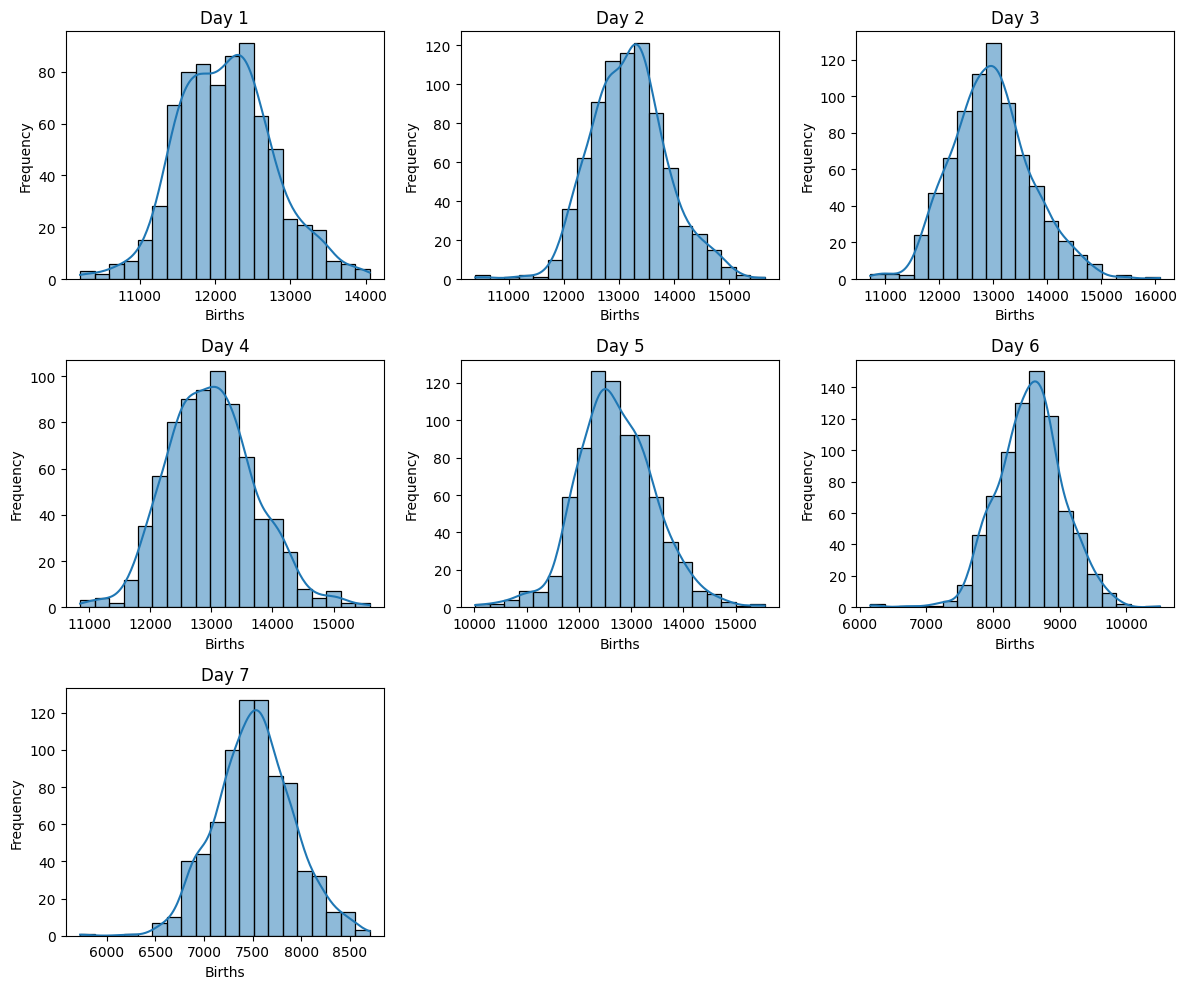

In [24]:
plt.figure(figsize=(12,10))
for i in range(1,8):
    plt.subplot(3,3,i)
    data = df[df['day_of_week'] == i]['births']
    sns.histplot(data, bins=20, kde=True)
    plt.title(f"Day {i}")
    plt.xlabel("Births")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<span style="font-size:15px;">The histograms and KDE plots illustrate the distribution of birth counts for each day of the week. Most plots show a roughly normal distribution, indicating that birth counts cluster around central values. Weekdays tend to have higher birth counts, while Weekend days show slightly lower values.</span>

<span style="font-size: 20px;">Find by what day of the year 50% of births have occurred for each year</span>

In [25]:
df = df.sort_values(['year','month','date_of_month'])

In [26]:
for year, data in df.groupby('year'):
    total = data['births'].sum()
    day = data[data['births'].cumsum() >= total/2].iloc[0]
    print(year, ":", "Month", day['month'], "Day", int(day['date_of_month']))

2000 : Month 7 Day 7
2001 : Month 7 Day 5
2002 : Month 7 Day 3
2003 : Month 7 Day 5
2004 : Month 7 Day 3
2005 : Month 7 Day 5
2006 : Month 7 Day 7
2007 : Month 7 Day 5
2008 : Month 7 Day 1
2009 : Month 7 Day 2
2010 : Month 7 Day 3
2011 : Month 7 Day 5
2012 : Month 7 Day 6
2013 : Month 7 Day 6
2014 : Month 7 Day 3


<span style="font-size:15px;">The cumulative number of births was calculated for each year. The first date where cumulative births reach 50% of the total births represents the midpoint of births for that year. The results show that this midpoint generally occurs around early July.</span>

<span style="font-size: 20px;">In 2000, between what days of the year do 50% of births occur</span>

In [27]:
total = data['births'].sum()
cumulative = data['births'].cumsum()

start = data[cumulative >= total*0.25].iloc[0]
end = data[cumulative >= total*0.75].iloc[0]

print("In 2000, 50% of births occurred between:")
print("Month", int(start['month']), "Day", int(start['date_of_month']),
      "and Month", int(end['month']), "Day", int(end['date_of_month']))

In 2000, 50% of births occurred between:
Month 4 Day 3 and Month 9 Day 27


<span style="font-size:15px;">To 50% of births in 2000 occurred between approximately April and September.</span>

<span style="font-size:15px;">To determine the period during which 50% of births occurred in the year 2000, cumulative birth counts were calculated. The dates at which cumulative births reached 25% and 75% of the total yearly births were identified. The period between these two dates represents the middle 50% of births during that year.</span>

<span style="font-size: 25px;">Conclusion</span>

<span style="font-size: 15px;">The analysis of the US Births dataset (2000–2014) revealed clear patterns in daily birth counts. Statistical measures such as mean, median, variance, and IQR helped understand the variability in birth data. Visualization techniques like box plots and histograms highlighted the distribution and presence of outliers. Overall, the analysis demonstrates how data preprocessing, statistical analysis, and visualization help uncover meaningful patterns in real-world datasets.